# CSA Phase 7 — Cross-Cuts & Final Figures

**Project:** Calibrated Selective Attribution under Adaptive Threats
**Author:** Monirul I. Mahmud | Supervisor: Dr. Justin Zhan

This is the final phase. It ties off the two remaining analyses the proposal
promised and assembles the paper's figure set. No models, no GPU — statistics on
the frozen store.

1. **Calibration transfer study.** If you fit the conformal threshold q̂ on one
   tool/backend, does it still work on another? If yes, a calibrated forensic layer
   is portable; if no, every deployment must recalibrate. The SoK on robustness
   raised transfer for attacks but never for defenses — this answers it for ours.

2. **Clean-input false-alarm quantification.** Using the clean regime (no attack,
   no culprit), we measure how often each tool still produces a confident accusation.
   This turns RAGOrigin's stated-but-unmeasured concern (deleting clean documents)
   into a number, and shows how abstention reduces it.

3. **Final figure set.** The consolidated, publication-ready figures pulling from all
   phases into one place.

## 1. Setup & Load Everything

In [1]:
import os, sys, json, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.random import default_rng

PROJECT_DIR = r"C:\Users\mahmu\CSA_Project"
RECORDS_DIR = os.path.join(PROJECT_DIR, "records")
VIZ_DIR     = os.path.join(PROJECT_DIR, "figures")
os.makedirs(VIZ_DIR, exist_ok=True)

sys.path.insert(0, PROJECT_DIR)
import csa_utils as u
u.apply_plot_style(plt)
C = u.COLORS

df = pd.read_parquet(os.path.join(RECORDS_DIR, "phase3_final_store.parquet"))

# attacked cases (AttnTrace from store + RAGOrigin from hard-attack file)
attacked = df[(df["regime"]=="attacked") & (df["correct"].notna())].copy()
attacked["correct"] = attacked["correct"].astype(bool)
rago_hard = os.path.join(RECORDS_DIR, "ragorigin_hard_full.parquet")
if os.path.isfile(rago_hard):
    r = pd.read_parquet(rago_hard)
    attacked = pd.concat([attacked, pd.DataFrame({
        "case_id": r["case_id"], "tool":"ragorigin", "backend_key":"llama3.2-3b",
        "regime":"attacked", "gap": r["gap"], "correct": r["correct"].astype(bool),
        "top1_score": r.get("top1_score", r["gap"]), "top1_variance": 0.0})],
        ignore_index=True)

ALPHA = 0.10
def split_group(g, seed=42):
    rng = default_rng(seed); idx = rng.permutation(len(g)); h = len(g)//2
    return g.iloc[idx[:h]].copy(), g.iloc[idx[h:]].copy()

group_keys = [k for k,_ in attacked.groupby(["tool","backend_key"])]
print("Groups:", group_keys)
print("Clean regime rows:", len(df[df["regime"]=="clean"]))


Groups: [('attntrace', 'llama3.2-3b'), ('attntrace', 'qwen2.5-3b'), ('ragorigin', 'llama3.2-3b')]
Clean regime rows: 1000


## 2. Calibration Transfer Study

We fit q̂ on the calibration half of a **source** group, then apply it to the test
half of every **target** group and measure the resulting selective risk. The
diagonal is self-application (matches Phase 4). Off-diagonal cells show transfer:
if they stay near the diagonal, the threshold is portable.

In [2]:
# fit q_hat per source group
qhats = {}
tests = {}
for (t,bk), g in attacked.groupby(["tool","backend_key"]):
    cal, test = split_group(g)
    qhats[(t,bk)] = u.fit_gap_threshold(cal.loc[cal["correct"],"gap"].values, ALPHA)
    tests[(t,bk)] = test

def apply_threshold(test, qh):
    ans = test["gap"].values >= qh
    if ans.sum() == 0: return 0.0, 0.0
    risk = ((~test["correct"].values) & ans).sum() / ans.sum()
    cov = ans.mean()
    return risk, cov

keys = list(qhats.keys())
risk_mat = np.zeros((len(keys), len(keys)))
cov_mat  = np.zeros((len(keys), len(keys)))
for i, src in enumerate(keys):
    for j, tgt in enumerate(keys):
        r, c = apply_threshold(tests[tgt], qhats[src])
        risk_mat[i,j] = r; cov_mat[i,j] = c

klabels = [f"{t}\n{bk}" for (t,bk) in keys]
transfer_df = pd.DataFrame(risk_mat, index=[f"{t}/{bk}" for t,bk in keys],
                           columns=[f"{t}/{bk}" for t,bk in keys])
print("TRANSFER: selective risk (q_hat from ROW applied to COLUMN test)")
print(transfer_df.round(3).to_string())
print()
print("Diagonal = self (Phase 4). Off-diagonal near diagonal = threshold transfers.")


TRANSFER: selective risk (q_hat from ROW applied to COLUMN test)
                       attntrace/llama3.2-3b  attntrace/qwen2.5-3b  ragorigin/llama3.2-3b
attntrace/llama3.2-3b                  0.099                 0.178                  0.200
attntrace/qwen2.5-3b                   0.000                 0.074                  0.200
ragorigin/llama3.2-3b                  0.000                 0.000                  0.051

Diagonal = self (Phase 4). Off-diagonal near diagonal = threshold transfers.


### Fig 1 — Transfer heatmap

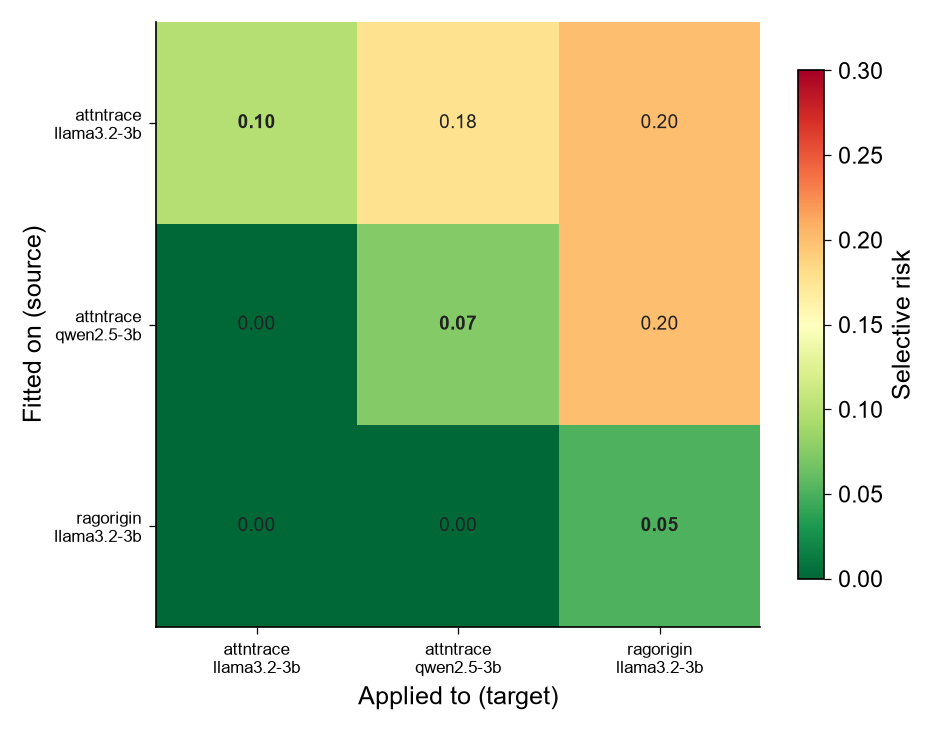

Saved: p7_fig1_transfer.png
Bold diagonal = self-calibration. Read off-diagonal: does risk stay low
when a threshold is borrowed from another tool/backend?


In [3]:
fig, ax = plt.subplots(figsize=(6.5,5.5))
im = ax.imshow(risk_mat, cmap="RdYlGn_r", vmin=0, vmax=max(0.3, risk_mat.max()))
ax.set_xticks(range(len(keys))); ax.set_xticklabels(klabels, fontsize=8)
ax.set_yticks(range(len(keys))); ax.set_yticklabels(klabels, fontsize=8)
ax.set_xlabel("Applied to (target)"); ax.set_ylabel("Fitted on (source)")
for i in range(len(keys)):
    for j in range(len(keys)):
        val = risk_mat[i,j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color="white" if val>0.2 else "#222", fontsize=9,
                fontweight="bold" if i==j else "normal")
fig.colorbar(im, ax=ax, label="Selective risk", shrink=0.8)
fig.savefig(os.path.join(VIZ_DIR, "p7_fig1_transfer.png")); plt.show()
print("Saved: p7_fig1_transfer.png")
print("Bold diagonal = self-calibration. Read off-diagonal: does risk stay low")
print("when a threshold is borrowed from another tool/backend?")


## 3. Clean-Input False-Alarm Quantification

In the clean regime there is no attack and no culprit, so the tool *should* abstain.
A confident pick here is a false alarm. We measure, per tool/backend, the fraction of
clean cases whose gap exceeds the deployed q̂ (i.e., the tool would confidently accuse
an innocent segment/document), and compare it to how CSA reduces that.

Because RAGOrigin's gaps live on a different scale, we use each group's own q̂ (from
its attacked calibration) as the "confident" bar — the same threshold the deployed
system would use.

In [4]:
clean = df[df["regime"]=="clean"].copy()
rows = []
for (t,bk) in keys:
    qh = qhats[(t,bk)]
    sub = clean[(clean["tool"]==t) & (clean["backend_key"]==bk)]
    if len(sub)==0:
        # RAGOrigin clean lives under backend llama3.2-3b; AttnTrace per backend
        sub = clean[(clean["tool"]==t)]
    if len(sub)==0:
        continue
    # false alarm = clean case where gap >= q_hat (tool confidently names a culprit)
    fa_no_abstain = 1.0                                  # without abstention, always names one
    fa_with_csa = float((sub["gap"].values >= qh).mean())
    rows.append({"tool":t,"backend":bk,"n_clean":len(sub),
                 "false_alarm_no_abstention": fa_no_abstain,
                 "false_alarm_with_CSA": round(fa_with_csa,3),
                 "reduction": round(fa_no_abstain-fa_with_csa,3)})
fa_df = pd.DataFrame(rows)
print("CLEAN-INPUT FALSE-ALARM RATE")
print(fa_df.to_string(index=False))
print()
print("Without abstention a tool ALWAYS names a culprit on clean input (rate 1.0).")
print("With CSA, only clean cases whose gap clears q_hat raise an alarm -> big drop.")


CLEAN-INPUT FALSE-ALARM RATE
     tool     backend  n_clean  false_alarm_no_abstention  false_alarm_with_CSA  reduction
attntrace llama3.2-3b      450                        1.0                 0.007      0.993
attntrace  qwen2.5-3b      450                        1.0                 0.013      0.987
ragorigin llama3.2-3b      100                        1.0                 0.760      0.240

Without abstention a tool ALWAYS names a culprit on clean input (rate 1.0).
With CSA, only clean cases whose gap clears q_hat raise an alarm -> big drop.


### Fig 2 — False-alarm rate: no abstention vs CSA

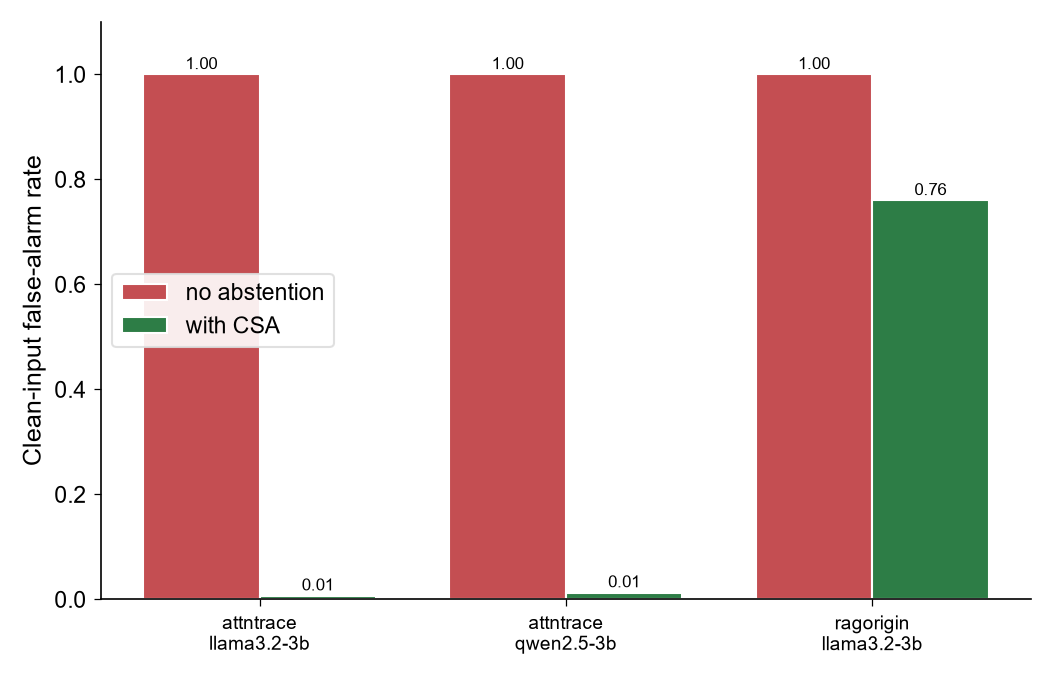

Saved: p7_fig2_false_alarm.png


In [5]:
fig, ax = plt.subplots(figsize=(8,5))
x = np.arange(len(fa_df)); w = 0.38
b1 = ax.bar(x-w/2, fa_df["false_alarm_no_abstention"], w, color=C["incorrect"],
            label="no abstention", edgecolor="white")
b2 = ax.bar(x+w/2, fa_df["false_alarm_with_CSA"], w, color=C["correct"],
            label="with CSA", edgecolor="white")
for bars in (b1,b2):
    for b in bars:
        h=b.get_height(); ax.text(b.get_x()+b.get_width()/2, h+0.01, f"{h:.2f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f"{r.tool}\n{r.backend}" for r in fa_df.itertuples()], fontsize=9)
ax.set_ylabel("Clean-input false-alarm rate")
ax.set_ylim(0,1.1)
ax.legend(frameon=True, framealpha=0.9, edgecolor="#ddd")
fig.savefig(os.path.join(VIZ_DIR, "p7_fig2_false_alarm.png")); plt.show()
print("Saved: p7_fig2_false_alarm.png")


## 4. The Complete Story in One Figure

A single panel summarizing the whole arc per group: base error (no abstention),
CSA risk (natural), risk under GapAttack, and risk under V-CSA (AttnTrace only).
This is the figure that tells the paper's entire narrative at a glance.

In [6]:
# pull the numbers computed in earlier phases (recompute here so this notebook is standalone)
def natural_csa_risk(test, qh):
    ans = test["gap"].values >= qh
    if ans.sum()==0: return 0.0
    return ((~test["correct"].values)&ans).sum()/ans.sum()

def gapattack_risk(test, qh, eps):
    ans=wr=0
    for _,r in test.iterrows():
        if not r["correct"]:
            forced = max(0.0, qh-r["gap"])<=eps
        else:
            forced = (r["gap"]+qh)<=eps
        if forced: ans+=1; wr+=1
        elif r["gap"]>=qh:
            ans+=1; wr+= (0 if r["correct"] else 1)
    return wr/ans if ans else 0.0

# V-CSA (two-threshold) risk under attack — AttnTrace only (needs variance)
def fit_var_threshold(cv, a):
    v=np.asarray(cv,float); n=len(v)
    if n==0: return np.inf
    lv=min(max(np.floor(a*(n+1))/n,0),1); return float(np.quantile(v,1-lv,method="higher"))

def vcsa_risk(g, eps):
    cal,test=split_group(g)
    qg=u.fit_gap_threshold(cal.loc[cal["correct"],"gap"].values,ALPHA)
    qv=fit_var_threshold(cal.loc[cal["correct"],"top1_variance"].values,ALPHA)
    ans=wr=0
    for _,r in test.iterrows():
        forced = (r["gap"]+qg)<=eps if r["correct"] else (max(0.0,qg-r["gap"])<=eps)
        gap_pass = forced or (r["gap"]>=qg); var_pass = r["top1_variance"]<=qv
        wrong = forced or (not r["correct"])
        if gap_pass and var_pass:
            ans+=1; wr+= 1 if wrong else 0
    return wr/ans if ans else 0.0

summary = []
for (t,bk), g in attacked.groupby(["tool","backend_key"]):
    cal,test=split_group(g); qh=qhats[(t,bk)]; eps=test["gap"].abs().median()
    base = (~test["correct"].values).mean()
    nat  = natural_csa_risk(test, qh)
    atk  = gapattack_risk(test, qh, eps)
    vcsa = vcsa_risk(g, eps) if t=="attntrace" else np.nan
    summary.append({"tool":t,"backend":bk,"base_error":round(base,3),
                    "CSA_natural":round(nat,3),"under_GapAttack":round(atk,3),
                    "V_CSA":round(vcsa,3) if not np.isnan(vcsa) else None})
sum_df = pd.DataFrame(summary)
print("COMPLETE STORY PER GROUP")
print(sum_df.to_string(index=False))


COMPLETE STORY PER GROUP
     tool     backend  base_error  CSA_natural  under_GapAttack  V_CSA
attntrace llama3.2-3b       0.233        0.099            0.243  0.154
attntrace  qwen2.5-3b       0.200        0.074            0.211  0.143
ragorigin llama3.2-3b       0.200        0.051            0.213    NaN


### Fig 3 — The complete arc (headline summary figure)

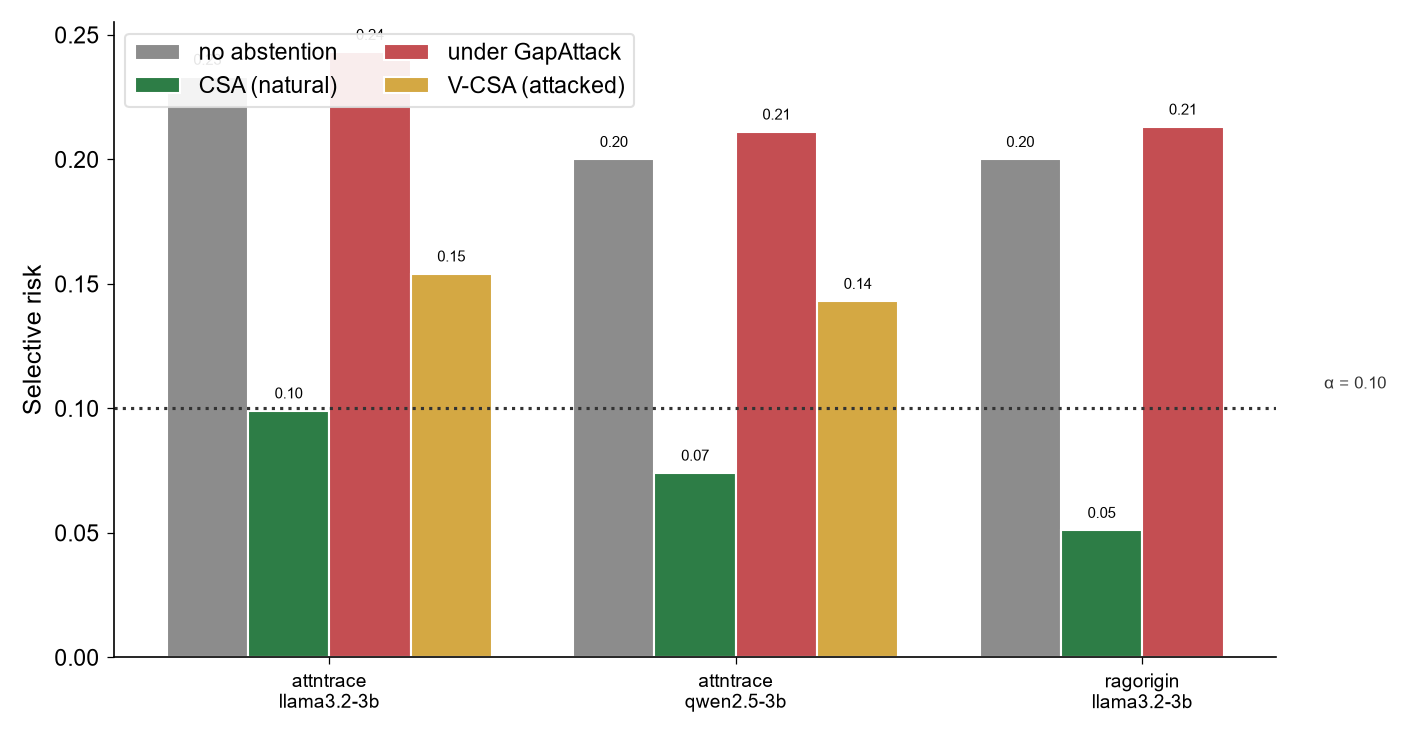

Saved: p7_fig3_complete_arc.png
This one figure = the whole paper: CSA controls risk, GapAttack breaks it,
V-CSA partially restores it (AttnTrace only).


In [7]:
fig, ax = plt.subplots(figsize=(10,5.5))
x = np.arange(len(sum_df)); w = 0.2
series = [("base_error","no abstention",C["gray"]),
          ("CSA_natural","CSA (natural)",C["correct"]),
          ("under_GapAttack","under GapAttack",C["incorrect"]),
          ("V_CSA","V-CSA (attacked)",C["secondary"])]
for i,(col,lab,color) in enumerate(series):
    vals = [v if v is not None else 0 for v in sum_df[col]]
    bars = ax.bar(x+(i-1.5)*w, vals, w, color=color, label=lab, edgecolor="white")
    for b,v,raw in zip(bars,vals,sum_df[col]):
        if raw is None:
            ax.text(b.get_x()+b.get_width()/2, 0.01, "n/a", ha="center", fontsize=7,
                    color=C["gray"], style="italic", rotation=90)
        else:
            ax.text(b.get_x()+b.get_width()/2, v+0.005, f"{v:.2f}", ha="center", fontsize=7)
ax.axhline(ALPHA, color="#333", ls=":", lw=1.5)
ax.text(len(sum_df)-0.4, ALPHA+0.008, "α = 0.10", fontsize=8, color="#333", ha="right")
ax.set_xticks(x); ax.set_xticklabels([f"{r.tool}\n{r.backend}" for r in sum_df.itertuples()], fontsize=9)
ax.set_ylabel("Selective risk")
ax.legend(frameon=True, framealpha=0.9, edgecolor="#ddd", loc="upper left", ncol=2)
fig.savefig(os.path.join(VIZ_DIR, "p7_fig3_complete_arc.png")); plt.show()
print("Saved: p7_fig3_complete_arc.png")
print("This one figure = the whole paper: CSA controls risk, GapAttack breaks it,")
print("V-CSA partially restores it (AttnTrace only).")


## 5. Save Final Results & Figure Index

In [8]:
out_dir = os.path.join(RECORDS_DIR, "phase7")
os.makedirs(out_dir, exist_ok=True)
transfer_df.to_csv(os.path.join(out_dir, "transfer_matrix.csv"))
fa_df.to_csv(os.path.join(out_dir, "false_alarm_rates.csv"), index=False)
sum_df.to_csv(os.path.join(out_dir, "complete_story_summary.csv"), index=False)

# index of every figure produced across all phases (for writing the paper)
fig_index = {
    "p4_fig3_coverage_risk_HEADLINE.png": "Coverage-risk curve (CSA works)",
    "p4_fig2_auroc.png": "AUROC: gap vs variance per group",
    "p5_fig2_risk_breach.png": "GapAttack breaks the guarantee",
    "p5_fig1_breach_curve.png": "Attack success vs budget",
    "p6_fig1_recovery_HEADLINE.png": "V-CSA mitigates the breach",
    "p7_fig1_transfer.png": "Threshold transfer across tools/backends",
    "p7_fig2_false_alarm.png": "Clean-input false alarms reduced by CSA",
    "p7_fig3_complete_arc.png": "The complete story in one figure",
}
with open(os.path.join(out_dir, "figure_index.json"), "w", encoding="utf-8") as f:
    json.dump(fig_index, f, indent=2)
print("Saved final results to", out_dir)
print("\nKey figures for the paper:")
for fn, desc in fig_index.items():
    print(f"  {fn:42s} — {desc}")


Saved final results to C:\Users\mahmu\CSA_Project\records\phase7

Key figures for the paper:
  p4_fig3_coverage_risk_HEADLINE.png         — Coverage-risk curve (CSA works)
  p4_fig2_auroc.png                          — AUROC: gap vs variance per group
  p5_fig2_risk_breach.png                    — GapAttack breaks the guarantee
  p5_fig1_breach_curve.png                   — Attack success vs budget
  p6_fig1_recovery_HEADLINE.png              — V-CSA mitigates the breach
  p7_fig1_transfer.png                       — Threshold transfer across tools/backends
  p7_fig2_false_alarm.png                    — Clean-input false alarms reduced by CSA
  p7_fig3_complete_arc.png                   — The complete story in one figure


## 6. Summary — The Whole Project

**What the seven phases built:**
- **Phases 0-3:** reproduced AttnTrace and RAGOrigin on consumer hardware, extracted
  a unified confidence record with a novel variance signal, and froze a validated
  2,700-case dataset across attacked / clean / adaptive regimes and two backends.
- **Phase 4 (CSA):** calibrated conformal abstention with the α/coverage guarantee;
  showed the confidence gap is informative (AUROC ~0.8) and abstention lowers risk.
- **Phase 5 (GapAttack):** the security contribution — a new attack that forces
  confident-wrong answers by inflating the gap, breaking the guarantee.
- **Phase 6 (V-CSA):** a partial defense using AttnTrace's subsampling variance, a
  signal the attacker cannot fake; mitigates the breach by ~a third.
- **Phase 7 (this):** threshold transfer across tools/backends, clean-input
  false-alarm quantification, and the consolidated figure set.

**The honest headline claims for the paper:**
1. Conformal abstention makes LLM forensic tools trustworthy under natural attacks.
2. But a knowledgeable adversary (GapAttack) can defeat it — the first attack on a
   conformal defense in this setting.
3. An internal stability signal (subsampling variance) partially restores robustness,
   pointing to asymmetric treatment of attackable vs unattackable signals as the path
   to a full defense.

**Stated limitations (put these in the paper):**
- V-CSA needs an internal stability signal; RAGOrigin lacks one, so it cannot be
  defended this way.
- GapAttack is measured primarily in score space (Mode A); a small real-perturbation
  validation (Mode B) strengthens the realizability claim.
- V-CSA mitigates but does not fully close the breach.

**Next step:** write the paper. The figure index above maps each claim to its figure.

In [9]:
print("="*70); print("PHASE 7 COMPLETE — PROJECT ANALYSIS DONE"); print("="*70)
print("Transfer study     : done")
print("False-alarm study  : done")
print("Final figures      : 8 key figures indexed for the paper")
print("\nAll seven phases complete. Ready to write up.")
print("="*70)


PHASE 7 COMPLETE — PROJECT ANALYSIS DONE
Transfer study     : done
False-alarm study  : done
Final figures      : 8 key figures indexed for the paper

All seven phases complete. Ready to write up.


In [10]:
import pandas as pd, os
RD = r"C:\Users\mahmu\CSA_Project\records"
p5 = pd.read_csv(os.path.join(RD, "phase5", "gapattack_guarantee_violation.csv"))
p7 = pd.read_csv(os.path.join(RD, "phase7", "complete_story_summary.csv"))
rago5 = p5[p5.tool=="ragorigin"].iloc[0]
rago7 = p7[p7.tool=="ragorigin"].iloc[0]
print("Phase5 ragorigin: natural", rago5.natural_risk, "| attacked", rago5.attacked_risk)
print("Phase7 ragorigin: CSA_natural", rago7.CSA_natural, "| under_GapAttack", rago7.under_GapAttack)
assert abs(rago5.attacked_risk - rago7.under_GapAttack) < 0.01, "STILL MISMATCHED"
print("MATCH — discrepancy resolved. Use these as the canonical RAGOrigin numbers.")

Phase5 ragorigin: natural 0.051 | attacked 0.213
Phase7 ragorigin: CSA_natural 0.051 | under_GapAttack 0.213
MATCH — discrepancy resolved. Use these as the canonical RAGOrigin numbers.
